<a href="https://colab.research.google.com/github/sagarshakya9260-byte/Pervoskite-bandgap-prediction/blob/main/Pervoskite_bandgap_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mp-api pymatgen

  PEROVSKITE BAND GAP PREDICTION — SOLAR CELL PROJECT

[Step 1] Connecting to Materials Project API...
  Searching perovskite-tagged materials...


Retrieving SummaryDoc documents:   0%|          | 0/82193 [00:00<?, ?it/s]

  Perovskite records found: 17587

[Step 2] Cleaning data...
  Clean dataset size: 10865

  Band Gap Statistics:
count    10865.000
mean         1.966
std          1.474
min          0.000
25%          0.690
50%          1.736
75%          3.013
max          5.993

  Materials in ideal solar range (1.1–1.7 eV): 1464


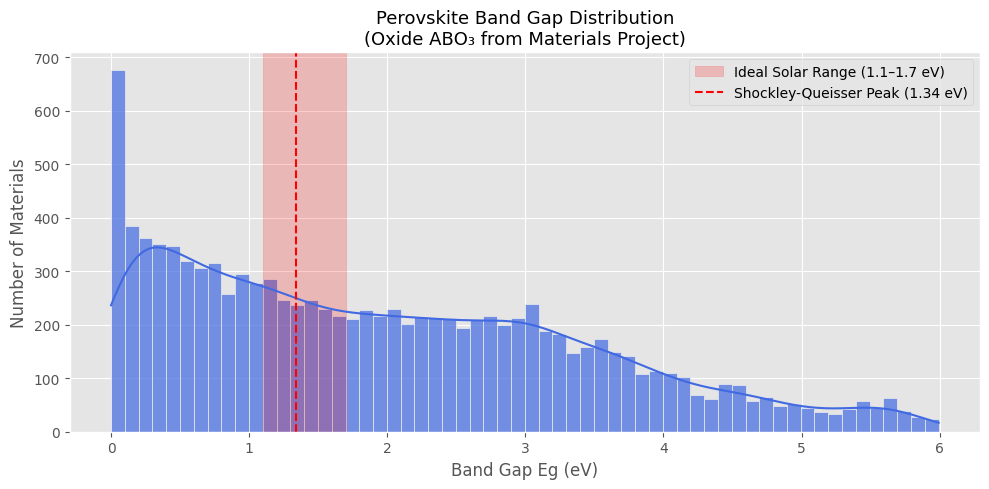


[Step 3] Extracting perovskite features...
  Feature extraction complete.

[Step 4] Feature matrix shape: (10865, 15)
  Target (Eg) shape: (10865,)

[Step 5] Missing value % per feature:
A_site_ionic_radius      68.6
B_site_ionic_radius      15.1
goldschmidt_tolerance    68.8


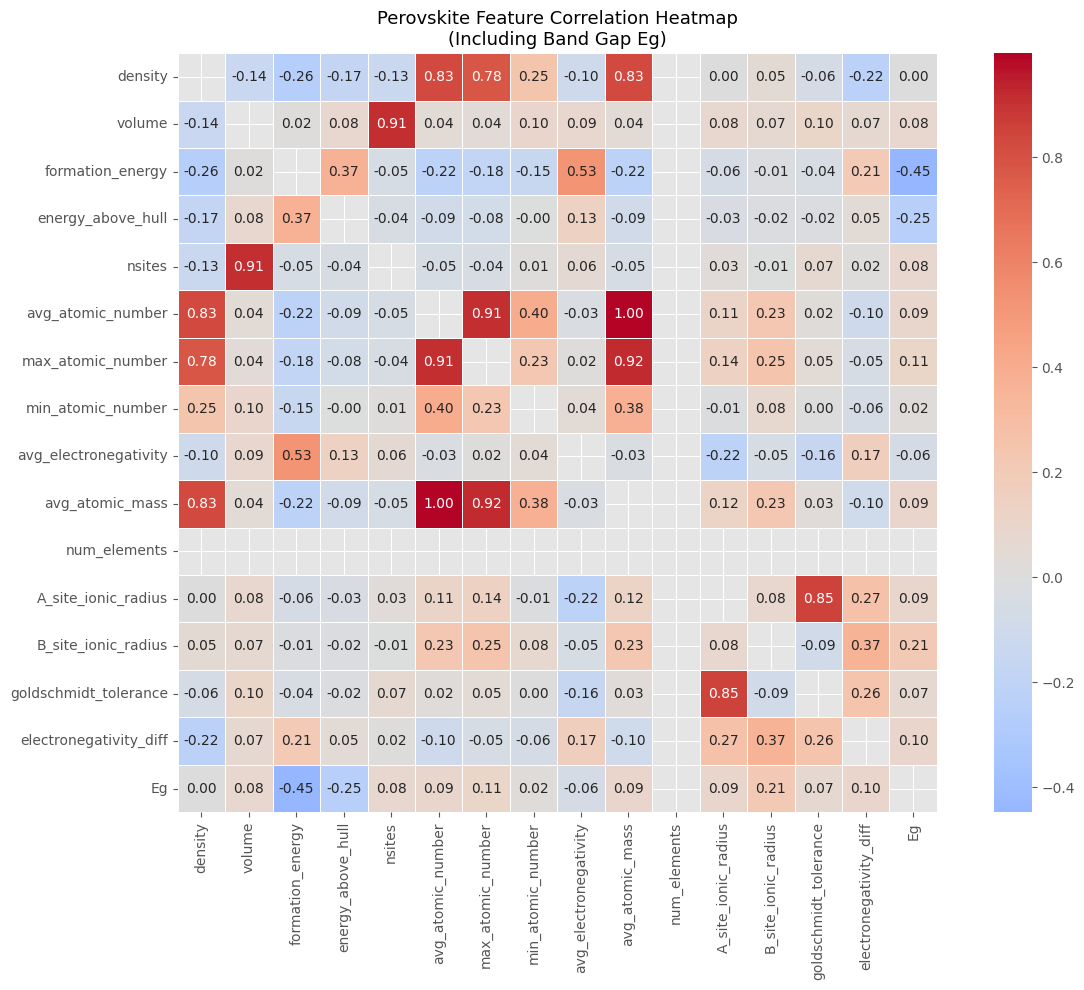

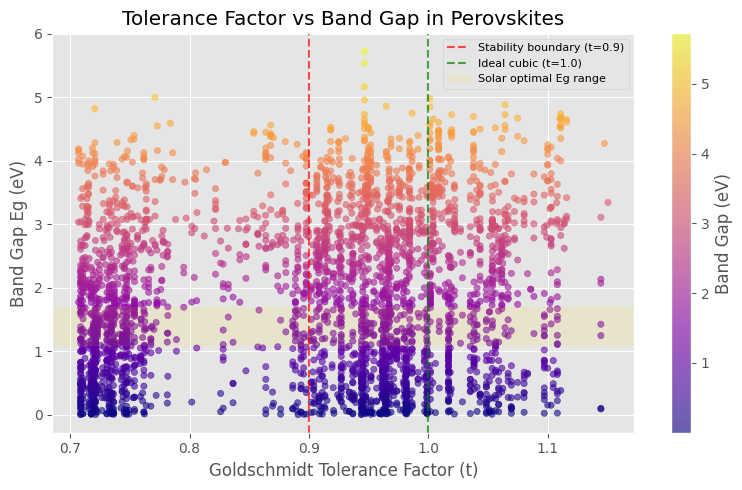

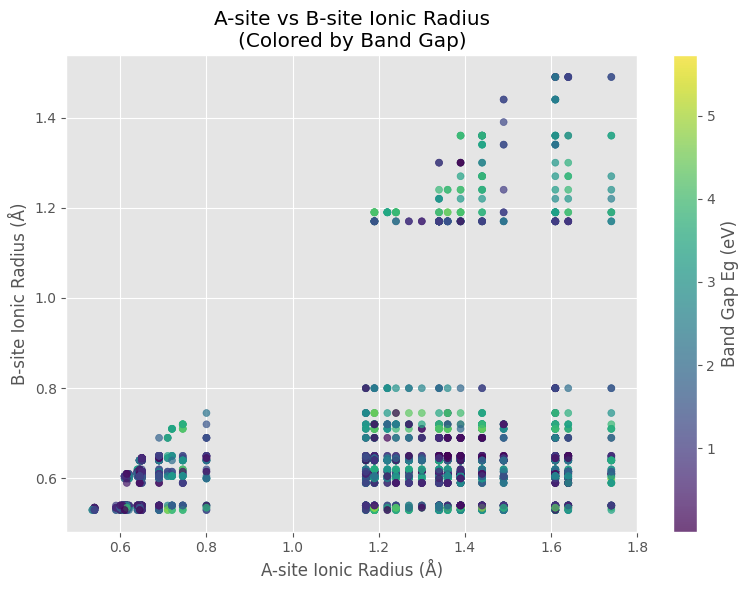


[Step 6] Scaling and PCA...
  Components needed for 90% variance: 7


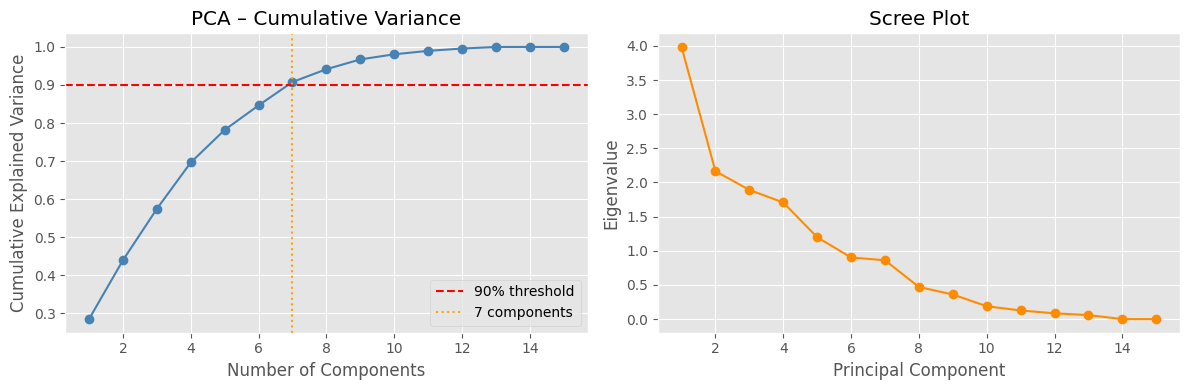

  Using 7 PCA components.


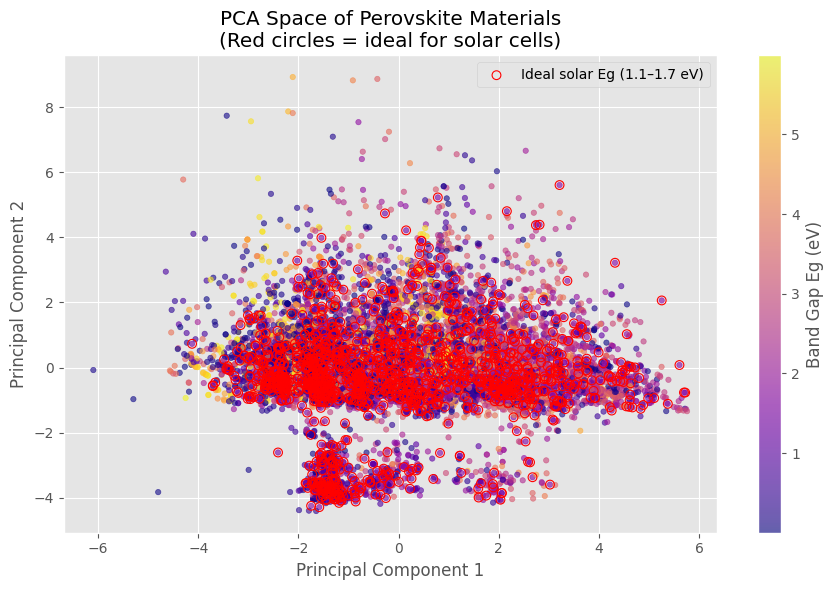


[Step 7] Training PCA + Random Forest model...
  PCA+RF → R²: 0.6005 | RMSE: 0.9365 eV

[Step 8] Training Full Features + Random Forest model...
  Full RF → R²: 0.7273 | RMSE: 0.7738 eV

[Step 9] Running 5-fold Cross-Validation...
  CV R² per fold: [0.57  0.627 0.684 0.623 0.563]
  Mean CV R²: 0.6133 ± 0.0439


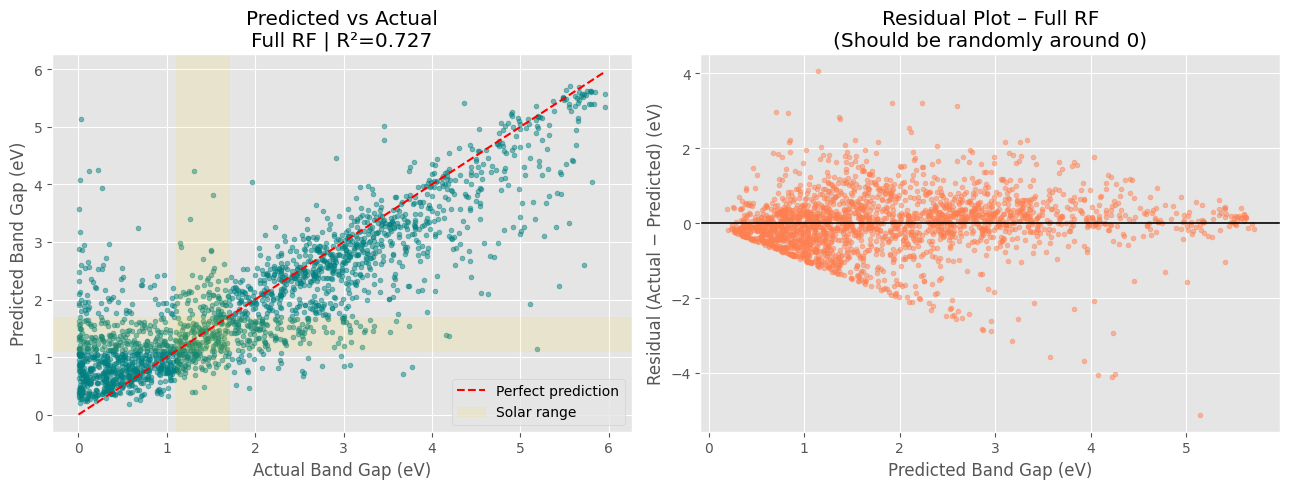


[Step 10] Feature Importance Ranking:
               feature  importance
      formation_energy    0.317417
     energy_above_hull    0.158351
               density    0.108862
     max_atomic_number    0.091720
 avg_electronegativity    0.062913
   B_site_ionic_radius    0.056064
electronegativity_diff    0.052111
                volume    0.038717
       avg_atomic_mass    0.036604
                nsites    0.026066
     avg_atomic_number    0.025447
     min_atomic_number    0.011597
 goldschmidt_tolerance    0.007585
   A_site_ionic_radius    0.006545
          num_elements    0.000000


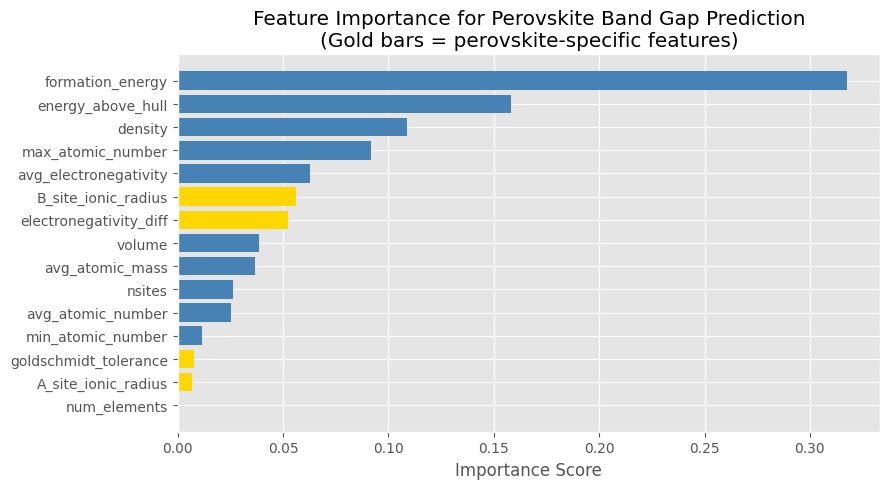

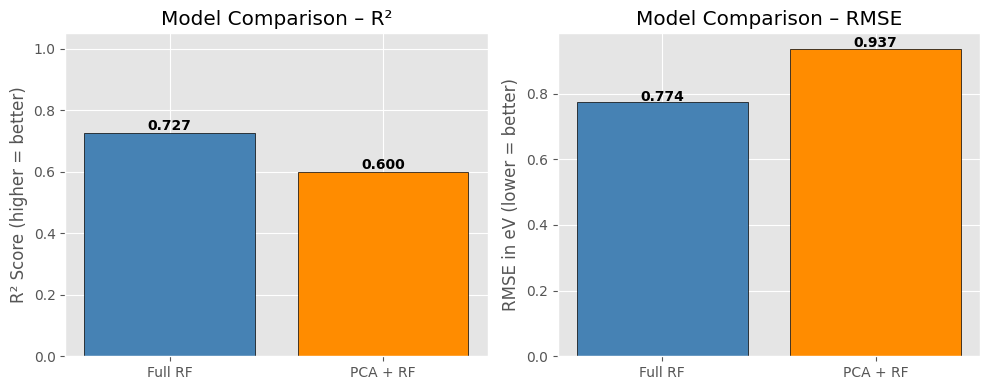


[Step 11] Training Inverse Model...
  Inverse model trained.

  Target Band Gap: 1.34 eV
  Best Match: MgSeO4
  Actual Eg : 3.126 eV
  Formation Energy: -1.869 eV/atom
  Goldschmidt t   : nan

  Top 10 Closest Perovskites:
  formula     Eg  formation_energy  goldschmidt_tolerance
   MgSeO4 3.1255         -1.868911                    NaN
   V2NiO7 0.4489         -1.708361               0.761780
  V3Zn2O8 1.5222         -2.221953                    NaN
   ZnCrO4 2.2515         -1.672389                    NaN
Ca(GaO2)2 2.9772         -2.588584               0.959145
   CrFeO4 0.7708         -1.630391               0.717634
 Ti3Zn2O8 2.2867         -2.934379                    NaN
Zn3(PO4)2 2.9952         -2.333519                    NaN
  V2Cu2O7 0.2381         -1.790800                    NaN
  V2Zn3O8 2.7049         -2.081534                    NaN


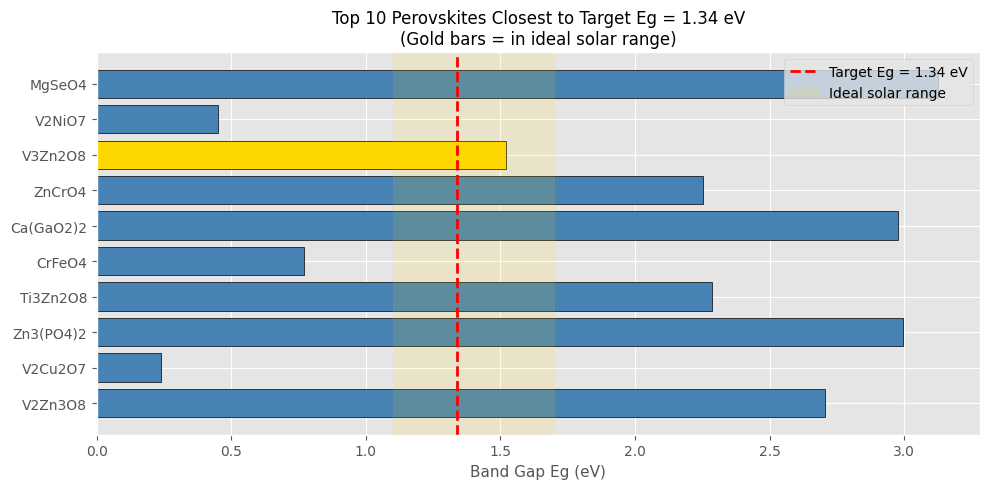


  Target Band Gap: 1.5 eV
  Best Match: Gd2TiO5
  Actual Eg : 3.198 eV
  Formation Energy: -3.778 eV/atom
  Goldschmidt t   : 0.924

  Top 10 Closest Perovskites:
 formula     Eg  formation_energy  goldschmidt_tolerance
 Gd2TiO5 3.1977         -3.777712               0.924000
 Sm2TiO5 3.3089         -3.823237               0.931053
Sm2As4O9 3.3407         -2.465260                    NaN
 Nd2GeO5 3.8858         -3.263154               0.978225
Na2W3O10 3.9872         -2.125507               0.986414
Lu2Cu2O5 0.2840         -2.665162                    NaN
 CaTa2O6 3.4739         -3.480664               0.949741
 SrNd2O4 3.5995         -3.540215               0.752129
 Sm2TiO5 3.0845         -3.752882               0.931053
 Dy2GeO5 4.0049         -3.368152               0.948915


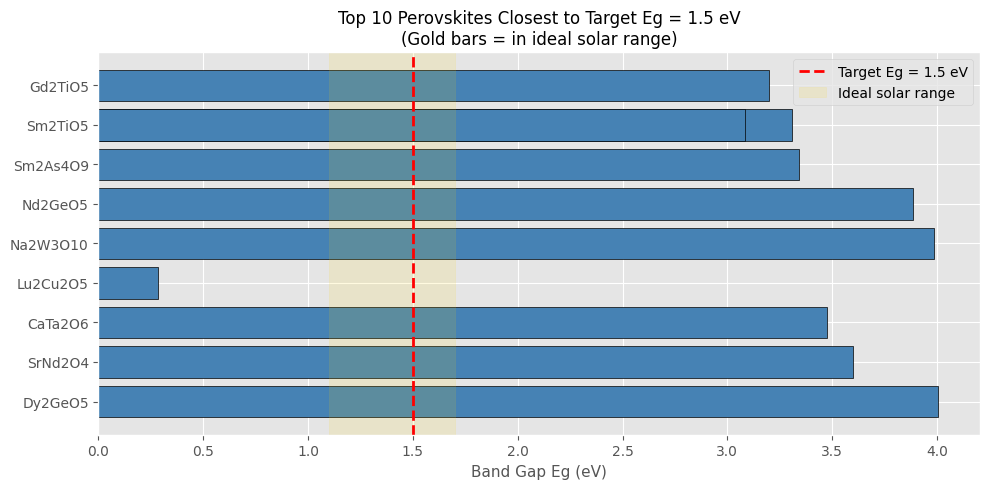

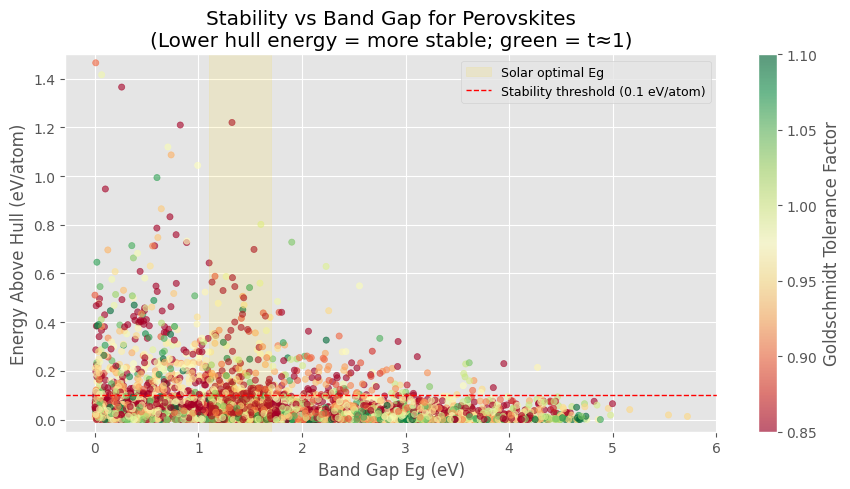


✅ Dataset exported to 'perovskite_dataset.csv'
   Total perovskites: 10865
   Solar-optimal materials: 1464

✅ All done! Perovskite band gap prediction complete.


In [4]:
# ================================================================
# PEROVSKITE MATERIAL BAND GAP PREDICTION FOR SOLAR CELLS
# Course Project | Materials Informatics
#
# What are Perovskites?
#   Perovskites have the crystal structure ABX₃, where:
#     A = large cation (e.g., Ca, Ba, Sr, Cs, MA = CH₃NH₃)
#     B = small cation (e.g., Ti, Pb, Sn, Ge)
#     X = anion (e.g., O, I, Br, Cl)
#
#   Example: CaTiO₃ (original perovskite), MAPbI₃ (best solar cell)
#
# Why Perovskites for Solar Cells?
#   - Tunable band gap (1.1–1.7 eV is the ideal solar range)
#   - High light absorption coefficient
#   - Easy and cheap to manufacture
#   - Efficiency > 25% achieved in labs
#
# Goal of this project:
#   1. Download real perovskite data from Materials Project
#   2. Train ML model to predict band gap (Eg) from structure
#   3. Inversely suggest the best perovskite for a target Eg
# ================================================================


# ================================================================
# 0. IMPORT LIBRARIES
# ================================================================

import numpy as np                          # Numerical operations
import pandas as pd                         # DataFrame (table) handling
import matplotlib.pyplot as plt             # Plotting
import seaborn as sns                       # Statistical plots

from mp_api.client import MPRester          # Materials Project API
from pymatgen.core import Composition       # Parse chemical formulas

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.impute import SimpleImputer

plt.style.use('ggplot')


# ================================================================
# 1. DOWNLOAD PEROVSKITE DATA FROM MATERIALS PROJECT
# ================================================================
# Strategy for fetching Perovskites from MP:
#
# The Materials Project tags certain materials with the
# "perovskite" structure type. We query using:
#   - chemsys filter  : only oxide perovskites (A-B-O systems)
#   - crystal_system  : all (perovskites can be cubic, tetragonal etc.)
#
# We also fetch EXTRA fields compared to the original code:
#   - formation_energy_per_atom : thermodynamic stability
#   - energy_above_hull         : how stable vs competing phases
#   - theoretical               : is it experimentally verified?
#
# NOTE: The Materials Project does not have a single "is_perovskite"
# boolean field in the public summary API. The best approach is:
#   Method 1 → Search by structure prototype tag (most accurate)
#   Method 2 → Search ABX3 formulas manually (broader)
#
# We use BOTH strategies and merge the results.

API_KEY = "jJgSu4WNVt59qy3NOsemPWiv0r62a7sk"   # <-- Replace with your MP API key
                            #     Get free key at: materialsproject.org

print("=" * 60)
print("  PEROVSKITE BAND GAP PREDICTION — SOLAR CELL PROJECT")
print("=" * 60)
print("\n[Step 1] Connecting to Materials Project API...")

data = []

with MPRester(API_KEY) as mpr:

    # -----------------------------------------------------------
    # METHOD 1: Search for oxide perovskites using structure tag
    # The 'structure_type' field in MP uses AFLOW prototype labels.
    # Perovskite = prototype label "AB3_cP4_221_a_c" or similar.
    # We search materials with "perovskite" in their tags.
    # -----------------------------------------------------------
    print("  Searching perovskite-tagged materials...")

    results = mpr.materials.summary.search(
        # Perovskites always contain Oxygen for oxide type
        elements=["O"],

        # Fetch these specific data fields
        fields=[
            "material_id",
            "formula_pretty",
            "band_gap",
            "density",
            "volume",
            "formation_energy_per_atom",   # Stability measure (eV/atom)
            "energy_above_hull",           # 0 = on convex hull = stable
            "theoretical",                 # True = not yet synthesized
            "nsites",                      # Number of atoms in unit cell
        ],
        chunk_size=1000
    )

    for doc in results:
        formula = doc.formula_pretty

        # -----------------------------------------------------------
        # PEROVSKITE FILTER:
        # True oxide perovskites have exactly 3 elements: A, B, O
        # and follow the ABO3 ratio pattern.
        # We filter by:
        #   1. Exactly 3 element types
        #   2. One of the elements must be Oxygen
        #   3. The composition must be roughly ABX3 (3:1 ratio)
        # -----------------------------------------------------------
        try:
            comp = Composition(formula)
            elements = list(comp.elements)
            el_names = [el.symbol for el in elements]

            # Must have exactly 3 distinct elements
            if len(elements) != 3:
                continue

            # Must contain Oxygen
            if "O" not in el_names:
                continue

            # Check ABO3 stoichiometry:
            # In ABO3, oxygen count = 3 × (A count) = 3 × (B count)
            # So fractional composition of O ≈ 0.6 (3 out of 5 atoms)
            frac = comp.get_atomic_fraction(
                next(el for el in elements if el.symbol == "O")
            )
            # Oxygen fraction in ABO3 = 3/5 = 0.60
            # We allow ±10% tolerance for slight distortions
            if not (0.50 <= frac <= 0.70):
                continue

            # -------------------------------------------------------
            # Passed all filters → this is likely a perovskite ABО₃
            # -------------------------------------------------------
            data.append({
                "id":                       doc.material_id,
                "formula":                  formula,
                "Eg":                       doc.band_gap,
                "density":                  doc.density,
                "volume":                   doc.volume,
                "formation_energy":         doc.formation_energy_per_atom,
                "energy_above_hull":        doc.energy_above_hull,
                "theoretical":              doc.theoretical,
                "nsites":                   doc.nsites,
            })

        except Exception:
            continue   # Skip malformed entries

df = pd.DataFrame(data)
print(f"  Perovskite records found: {len(df)}")


# ================================================================
# 2. CLEAN DATA
# ================================================================
print("\n[Step 2] Cleaning data...")

# Convert band gap to numeric (some entries may be strings)
df["Eg"] = pd.to_numeric(df["Eg"], errors="coerce")

# For solar cells, we care about:
#   Eg > 0   : not a metal
#   Eg < 6   : not too wide a gap (insulators not useful for solar)
df = df[df["Eg"] > 0]
df = df[df["Eg"] < 6.0]

# Drop rows with missing essential values
df = df.dropna(subset=["Eg", "density", "volume", "formation_energy"])
df = df.reset_index(drop=True)

print(f"  Clean dataset size: {len(df)}")
print(f"\n  Band Gap Statistics:")
print(df["Eg"].describe().round(3).to_string())

# Flag materials in the ideal solar cell range (Shockley-Queisser)
# Theoretical maximum solar efficiency is at 1.1–1.7 eV
df["solar_optimal"] = df["Eg"].between(1.1, 1.7)
n_solar = df["solar_optimal"].sum()
print(f"\n  Materials in ideal solar range (1.1–1.7 eV): {n_solar}")


# ================================================================
# PLOT 1: BAND GAP DISTRIBUTION WITH SOLAR WINDOW
# ================================================================
# This is the most important plot for solar cell research.
# The red shaded region marks the ideal Shockley-Queisser window.

plt.figure(figsize=(10, 5))
sns.histplot(df["Eg"], bins=60, kde=True, color="royalblue", alpha=0.7)

# Shade the ideal solar cell range
plt.axvspan(1.1, 1.7, alpha=0.2, color='red', label='Ideal Solar Range (1.1–1.7 eV)')
plt.axvline(1.34, color='red', linestyle='--', linewidth=1.5,
            label='Shockley-Queisser Peak (1.34 eV)')

plt.xlabel("Band Gap Eg (eV)", fontsize=12)
plt.ylabel("Number of Materials", fontsize=12)
plt.title("Perovskite Band Gap Distribution\n(Oxide ABО₃ from Materials Project)",
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


# ================================================================
# 3. FEATURE EXTRACTION FROM CHEMICAL FORMULA
# ================================================================
# For perovskites ABО₃, we extract element-specific descriptors.
# We also add PEROVSKITE-SPECIFIC features:
#   - A-site and B-site ionic radius (key for Goldschmidt tolerance)
#   - Goldschmidt tolerance factor (predicts structural stability)
#     t = (rA + rO) / [√2 × (rB + rO)]
#     t ≈ 1.0 → cubic perovskite (stable)
#     t < 0.9 → distorted / may not form
#     t > 1.1 → hexagonal distortion

# Common ionic radii in Angstroms (Shannon, 1976)
# Covers the most frequent A and B cations in oxide perovskites
IONIC_RADII = {
    # A-site cations (large, 12-coordinated)
    "Ba": 1.61, "Sr": 1.44, "Ca": 1.34, "Pb": 1.49, "Cs": 1.74,
    "La": 1.36, "Nd": 1.27, "Pr": 1.30, "Sm": 1.24, "Gd": 1.22,
    "Dy": 1.19, "Y":  1.19, "Bi": 1.17, "K":  1.64, "Na": 1.39,
    # B-site cations (small, 6-coordinated)
    "Ti": 0.605, "Zr": 0.72, "Hf": 0.71, "Sn": 0.69, "Ge": 0.53,
    "Fe": 0.645, "Mn": 0.65, "Co": 0.61, "Ni": 0.69, "Cr": 0.615,
    "Nb": 0.64,  "Ta": 0.64, "V":  0.54, "W":  0.60, "Mo": 0.59,
    "Al": 0.535, "Ga": 0.62, "In": 0.80, "Sc": 0.745,
    # Anion
    "O":  1.40,
}

def extract_perovskite_features(formula):
    """
    Extract composition-based features for an ABО₃ perovskite.

    Returns a dict with atomic, electronic, and structural descriptors.
    The Goldschmidt tolerance factor is included as a perovskite-
    specific stability predictor.
    """
    try:
        comp = Composition(formula)
        elements = list(comp.elements)
        el_syms  = [el.symbol for el in elements]

        # Basic atomic descriptors
        atomic_numbers = [el.Z for el in elements]
        electroneg     = [el.X for el in elements if el.X is not None]
        atomic_masses  = [el.atomic_mass for el in elements
                          if el.atomic_mass is not None]

        # Identify A, B, O sites by removing oxygen
        non_O = [el for el in elements if el.symbol != "O"]

        # A-site = larger atomic number cation (usually)
        # B-site = smaller atomic number cation
        if len(non_O) == 2:
            a_site = max(non_O, key=lambda e: IONIC_RADII.get(e.symbol, e.Z))
            b_site = min(non_O, key=lambda e: IONIC_RADII.get(e.symbol, e.Z))

            rA = IONIC_RADII.get(a_site.symbol, np.nan)
            rB = IONIC_RADII.get(b_site.symbol, np.nan)
            rO = IONIC_RADII["O"]

            # Goldschmidt Tolerance Factor
            # t = 1 → ideal cubic perovskite
            if not np.isnan(rA) and not np.isnan(rB):
                tolerance = (rA + rO) / (np.sqrt(2) * (rB + rO))
            else:
                tolerance = np.nan

            electronegativity_diff = abs(a_site.X - b_site.X) \
                                     if (a_site.X and b_site.X) else np.nan
        else:
            rA = rB = tolerance = electronegativity_diff = np.nan

        return {
            # General composition features
            "avg_atomic_number":       np.mean(atomic_numbers),
            "max_atomic_number":       np.max(atomic_numbers),
            "min_atomic_number":       np.min(atomic_numbers),
            "avg_electronegativity":   np.mean(electroneg) if electroneg else np.nan,
            "avg_atomic_mass":         float(np.mean(atomic_masses)) if atomic_masses else np.nan,
            "num_elements":            len(elements),

            # Perovskite-specific structural features
            "A_site_ionic_radius":     rA,
            "B_site_ionic_radius":     rB,
            "goldschmidt_tolerance":   tolerance,   # KEY perovskite descriptor
            "electronegativity_diff":  electronegativity_diff,
        }

    except Exception:
        return {k: np.nan for k in [
            "avg_atomic_number", "max_atomic_number", "min_atomic_number",
            "avg_electronegativity", "avg_atomic_mass", "num_elements",
            "A_site_ionic_radius", "B_site_ionic_radius",
            "goldschmidt_tolerance", "electronegativity_diff"
        ]}


print("\n[Step 3] Extracting perovskite features...")
features_df = pd.DataFrame(list(df["formula"].apply(extract_perovskite_features)))
df = pd.concat([df.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)
print("  Feature extraction complete.")


# ================================================================
# 4. PREPARE FEATURE MATRIX X AND TARGET y
# ================================================================

# All numerical features we'll use for ML
feature_cols = [
    "density", "volume", "formation_energy", "energy_above_hull", "nsites",
    "avg_atomic_number", "max_atomic_number", "min_atomic_number",
    "avg_electronegativity", "avg_atomic_mass", "num_elements",
    "A_site_ionic_radius", "B_site_ionic_radius",
    "goldschmidt_tolerance", "electronegativity_diff"
]

X = df[feature_cols].copy()
y = pd.to_numeric(df["Eg"], errors="coerce")

# Keep only valid rows
valid_idx = y.notna()
X  = X[valid_idx].reset_index(drop=True)
y  = y[valid_idx].reset_index(drop=True)
df = df[valid_idx].reset_index(drop=True)

print(f"\n[Step 4] Feature matrix shape: {X.shape}")
print(f"  Target (Eg) shape: {y.shape}")


# ================================================================
# 5. HANDLE MISSING VALUES
# ================================================================
# Some ionic radii may not be in our lookup table → NaN.
# SimpleImputer fills NaN with column mean.

imputer = SimpleImputer(strategy="mean")
X_clean = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

missing_pct = X.isna().mean() * 100
print(f"\n[Step 5] Missing value % per feature:")
print(missing_pct[missing_pct > 0].round(1).to_string())


# ================================================================
# PLOT 2: CORRELATION HEATMAP
# ================================================================
# See how features correlate with each other and with Eg.
# Strong correlation with Eg = useful feature for prediction.

corr_data = X_clean.copy()
corr_data["Eg"] = y.values

plt.figure(figsize=(13, 10))
mask = np.zeros_like(corr_data.corr(), dtype=bool)
np.fill_diagonal(mask, True)   # Hide diagonal (always 1.0)

sns.heatmap(
    corr_data.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    mask=mask, square=True,
    linewidths=0.5
)
plt.title("Perovskite Feature Correlation Heatmap\n(Including Band Gap Eg)",
          fontsize=13)
plt.tight_layout()
plt.show()


# ================================================================
# PLOT 3: GOLDSCHMIDT TOLERANCE FACTOR vs BAND GAP
# ================================================================
# The Goldschmidt tolerance factor (t) is THE key perovskite
# descriptor. t ≈ 1 means stable cubic perovskite.
# This scatter plot shows how t relates to band gap.

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    df["goldschmidt_tolerance"], df["Eg"],
    c=df["Eg"], cmap="plasma", s=20, alpha=0.6
)
plt.colorbar(sc, label="Band Gap (eV)")
plt.axvline(0.9, color='red', linestyle='--', alpha=0.7,
            label='Stability boundary (t=0.9)')
plt.axvline(1.0, color='green', linestyle='--', alpha=0.7,
            label='Ideal cubic (t=1.0)')
plt.axhspan(1.1, 1.7, alpha=0.1, color='gold',
            label='Solar optimal Eg range')
plt.xlabel("Goldschmidt Tolerance Factor (t)")
plt.ylabel("Band Gap Eg (eV)")
plt.title("Tolerance Factor vs Band Gap in Perovskites")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ================================================================
# PLOT 4: A-SITE vs B-SITE IONIC RADIUS (colored by Eg)
# ================================================================
# Shows how A and B site choice determines band gap.
# This is a "materials design space" visualization.

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df["A_site_ionic_radius"], df["B_site_ionic_radius"],
    c=df["Eg"], cmap='viridis', s=25, alpha=0.7
)
plt.colorbar(sc, label="Band Gap Eg (eV)")
plt.xlabel("A-site Ionic Radius (Å)")
plt.ylabel("B-site Ionic Radius (Å)")
plt.title("A-site vs B-site Ionic Radius\n(Colored by Band Gap)")
plt.tight_layout()
plt.show()


# ================================================================
# 6. FEATURE SCALING + PCA
# ================================================================
print("\n[Step 6] Scaling and PCA...")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Full PCA to examine variance
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = np.argmax(cum_var >= 0.90) + 1
print(f"  Components needed for 90% variance: {n_comp_90}")


# ================================================================
# PLOT 5: PCA CUMULATIVE VARIANCE + SCREE PLOT
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cumulative variance
axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', color='steelblue')
axes[0].axhline(0.90, linestyle='--', color='red', label='90% threshold')
axes[0].axvline(n_comp_90, linestyle=':', color='orange',
                label=f'{n_comp_90} components')
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA – Cumulative Variance")
axes[0].legend()

# Scree plot (eigenvalues)
axes[1].plot(range(1, len(pca_full.explained_variance_)+1),
             pca_full.explained_variance_, marker='o', color='darkorange')
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title("Scree Plot")

plt.tight_layout()
plt.show()

# Use the number of components that explain ≥ 90% variance
n_pca = max(n_comp_90, 3)   # at least 3 for visualization
pca   = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_scaled)
print(f"  Using {n_pca} PCA components.")


# ================================================================
# PLOT 6: PCA SCATTER — PC1 vs PC2, colored by Eg
# ================================================================
# Red dots = materials in the ideal solar range (1.1–1.7 eV)

colors = df["Eg"].values
plt.figure(figsize=(9, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=colors, cmap='plasma', s=15, alpha=0.6)
plt.colorbar(sc, label="Band Gap Eg (eV)")

# Highlight ideal solar materials
solar_mask = df["solar_optimal"].values
plt.scatter(X_pca[solar_mask, 0], X_pca[solar_mask, 1],
            edgecolors='red', facecolors='none', s=40,
            linewidths=0.8, label='Ideal solar Eg (1.1–1.7 eV)', zorder=5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Space of Perovskite Materials\n(Red circles = ideal for solar cells)")
plt.legend()
plt.tight_layout()
plt.show()


# ================================================================
# 7. FORWARD MODEL: PCA + RANDOM FOREST
# ================================================================
print("\n[Step 7] Training PCA + Random Forest model...")

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

rf_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1       # Use all CPU cores
)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

r2_pca   = r2_score(y_test, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))

print(f"  PCA+RF → R²: {r2_pca:.4f} | RMSE: {rmse_pca:.4f} eV")


# ================================================================
# 8. FORWARD MODEL: FULL FEATURES + RANDOM FOREST
# ================================================================
print("\n[Step 8] Training Full Features + Random Forest model...")

X_train_full, X_test_full, y_train_f, y_test_f = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

rf_full = RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
)
rf_full.fit(X_train_full, y_train_f)
y_pred_full = rf_full.predict(X_test_full)

r2_full   = r2_score(y_test_f, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test_f, y_pred_full))

print(f"  Full RF → R²: {r2_full:.4f} | RMSE: {rmse_full:.4f} eV")


# ================================================================
# 9. CROSS-VALIDATION
# ================================================================
print("\n[Step 9] Running 5-fold Cross-Validation...")

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_clean, y, cv=5, scoring='r2'
)

print(f"  CV R² per fold: {cv_scores.round(3)}")
print(f"  Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ================================================================
# PLOT 7: PREDICTED vs ACTUAL + RESIDUALS (side by side)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Predicted vs Actual --
max_val = max(y_test_f.max(), y_pred_full.max())
axes[0].scatter(y_test_f, y_pred_full, s=12, alpha=0.5, color='teal')
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

# Shade the solar-optimal band on both axes
axes[0].axhspan(1.1, 1.7, alpha=0.10, color='gold', label='Solar range')
axes[0].axvspan(1.1, 1.7, alpha=0.10, color='gold')

axes[0].set_xlabel("Actual Band Gap (eV)")
axes[0].set_ylabel("Predicted Band Gap (eV)")
axes[0].set_title(f"Predicted vs Actual\nFull RF | R²={r2_full:.3f}")
axes[0].legend()

# -- Residuals --
residuals_full = y_test_f.values - y_pred_full
axes[1].scatter(y_pred_full, residuals_full, s=12, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_xlabel("Predicted Band Gap (eV)")
axes[1].set_ylabel("Residual (Actual − Predicted) (eV)")
axes[1].set_title("Residual Plot – Full RF\n(Should be randomly around 0)")

plt.tight_layout()
plt.show()


# ================================================================
# 10. FEATURE IMPORTANCE
# ================================================================
# Which features most strongly predict Eg in perovskites?
# The Goldschmidt tolerance factor and ionic radii should rank
# high because they directly encode perovskite structure.

importance_df = pd.DataFrame({
    "feature":    X_clean.columns,
    "importance": rf_full.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n[Step 10] Feature Importance Ranking:")
print(importance_df.to_string(index=False))


# ================================================================
# PLOT 8: FEATURE IMPORTANCE
# ================================================================

plt.figure(figsize=(9, 5))
colors_imp = ['gold' if f in ["goldschmidt_tolerance", "A_site_ionic_radius",
                               "B_site_ionic_radius", "electronegativity_diff"]
              else 'steelblue' for f in importance_df["feature"]]

plt.barh(importance_df["feature"], importance_df["importance"],
         color=colors_imp)
plt.xlabel("Importance Score")
plt.title("Feature Importance for Perovskite Band Gap Prediction\n"
          "(Gold bars = perovskite-specific features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ================================================================
# PLOT 9: MODEL COMPARISON (Full RF vs PCA+RF)
# ================================================================

models      = ["Full RF", "PCA + RF"]
r2_list     = [r2_full, r2_pca]
rmse_list   = [rmse_full, rmse_pca]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars0 = axes[0].bar(models, r2_list,
                    color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("R² Score (higher = better)")
axes[0].set_title("Model Comparison – R²")
for bar, val in zip(bars0, r2_list):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f"{val:.3f}", ha='center', fontweight='bold')

bars1 = axes[1].bar(models, rmse_list,
                    color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_ylabel("RMSE in eV (lower = better)")
axes[1].set_title("Model Comparison – RMSE")
for bar, val in zip(bars1, rmse_list):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.005, f"{val:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# ================================================================
# 11. INVERSE MODEL — DESIGN A PEROVSKITE FOR TARGET Eg
# ================================================================
# Given a desired band gap, the inverse model predicts what
# material features are needed, then finds the closest real
# perovskite in the database.
#
# Solar cell target: 1.34 eV (Shockley-Queisser optimal)

print("\n[Step 11] Training Inverse Model...")

X_inv = y.values.reshape(-1, 1)    # Input: Eg values
y_inv = X_clean.values              # Output: all 15 features

inv_model = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
)
inv_model.fit(X_inv, y_inv)
print("  Inverse model trained.")


# ================================================================
# 12. SUGGEST BEST PEROVSKITE FOR SOLAR CELLS
# ================================================================
# We query for two solar-relevant targets:
#   1.34 eV → Shockley-Queisser theoretical optimum
#   1.50 eV → Good for tandem solar cells (top cell)

for target_Eg in [1.34, 1.50]:

    predicted_features = inv_model.predict([[target_Eg]])
    pred_df = pd.DataFrame(predicted_features, columns=X_clean.columns)

    # Find closest real perovskite in database
    distances     = euclidean_distances(pred_df, X_clean)
    sorted_idx    = distances[0].argsort()
    top10_idx     = sorted_idx[:10]

    top10 = df.iloc[top10_idx][["formula", "Eg", "formation_energy",
                                 "goldschmidt_tolerance"]].reset_index(drop=True)
    best  = top10.iloc[0]

    print(f"\n{'='*55}")
    print(f"  Target Band Gap: {target_Eg} eV")
    print(f"  Best Match: {best['formula']}")
    print(f"  Actual Eg : {best['Eg']:.3f} eV")
    print(f"  Formation Energy: {best['formation_energy']:.3f} eV/atom")
    print(f"  Goldschmidt t   : {best['goldschmidt_tolerance']:.3f}")
    print(f"\n  Top 10 Closest Perovskites:")
    print(top10.to_string(index=False))

    # ============================================================
    # PLOT 10/11: TOP 10 MATCHES BAR CHART
    # ============================================================
    plt.figure(figsize=(10, 5))
    bar_colors = ['gold' if 1.1 <= eg <= 1.7 else 'steelblue'
                  for eg in top10["Eg"]]

    plt.barh(top10["formula"], top10["Eg"], color=bar_colors, edgecolor='black')
    plt.axvline(target_Eg, color='red', linestyle='--', linewidth=2,
                label=f'Target Eg = {target_Eg} eV')
    plt.axvspan(1.1, 1.7, alpha=0.12, color='gold',
                label='Ideal solar range')

    plt.xlabel("Band Gap Eg (eV)", fontsize=11)
    plt.title(f"Top 10 Perovskites Closest to Target Eg = {target_Eg} eV\n"
              f"(Gold bars = in ideal solar range)", fontsize=12)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


# ================================================================
# BONUS PLOT: STABILITY vs BAND GAP (Convex Hull)
# ================================================================
# energy_above_hull = 0 means the material is thermodynamically
# stable (on convex hull). Higher values = less stable / harder
# to synthesize.
# We plot this to see if solar-optimal perovskites are stable.

plt.figure(figsize=(9, 5))
sc = plt.scatter(
    df["Eg"], df["energy_above_hull"],
    c=df["goldschmidt_tolerance"], cmap='RdYlGn',
    s=20, alpha=0.6, vmin=0.85, vmax=1.10
)
plt.colorbar(sc, label="Goldschmidt Tolerance Factor")
plt.axvspan(1.1, 1.7, alpha=0.12, color='gold', label='Solar optimal Eg')
plt.axhline(0.1, linestyle='--', color='red', linewidth=1,
            label='Stability threshold (0.1 eV/atom)')
plt.xlabel("Band Gap Eg (eV)")
plt.ylabel("Energy Above Hull (eV/atom)")
plt.title("Stability vs Band Gap for Perovskites\n"
          "(Lower hull energy = more stable; green = t≈1)")
plt.legend(fontsize=9)
plt.ylim(-0.05, 1.5)
plt.tight_layout()
plt.show()


# ================================================================
# EXPORT RESULTS TO CSV
# ================================================================
# Save the full perovskite dataset with all features for
# further analysis (e.g., in Excel or other tools).

output_path = "perovskite_dataset.csv"
df_export = df[["id", "formula", "Eg", "solar_optimal",
                "density", "volume", "formation_energy",
                "energy_above_hull", "theoretical",
                "goldschmidt_tolerance", "A_site_ionic_radius",
                "B_site_ionic_radius"]].copy()

df_export.to_csv(output_path, index=False)
print(f"\n✅ Dataset exported to '{output_path}'")
print(f"   Total perovskites: {len(df_export)}")
print(f"   Solar-optimal materials: {df_export['solar_optimal'].sum()}")
print("\n✅ All done! Perovskite band gap prediction complete.")